<a href="https://colab.research.google.com/github/srvnkumr27/flyrank-ml-internship/blob/main/w04_signal_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/srvnkumr27/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

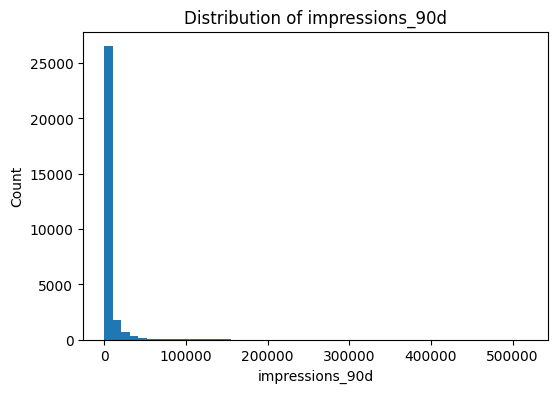

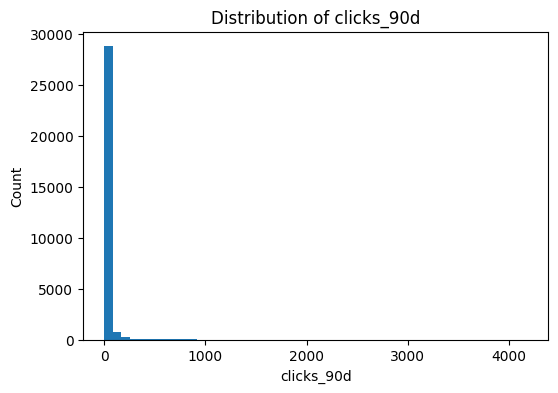

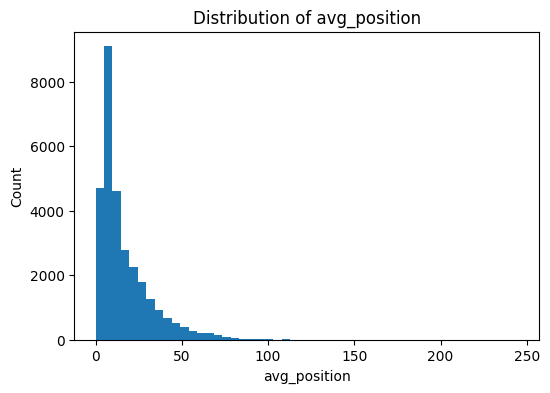

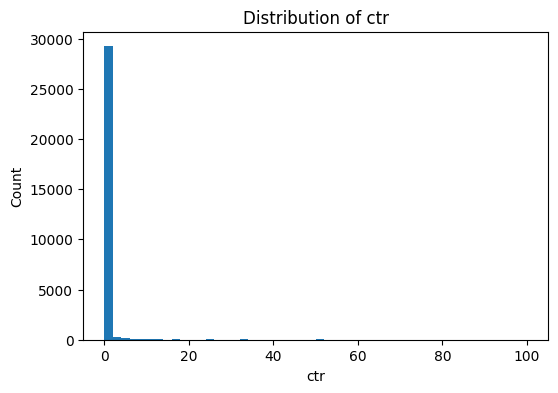

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/content/content_refresh_anonymized.csv')

features = [
    "impressions_90d",
    "clicks_90d",
    "avg_position",
    "ctr"
]

for col in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*


--- Signal Test #1: Impressions vs Clicks ---


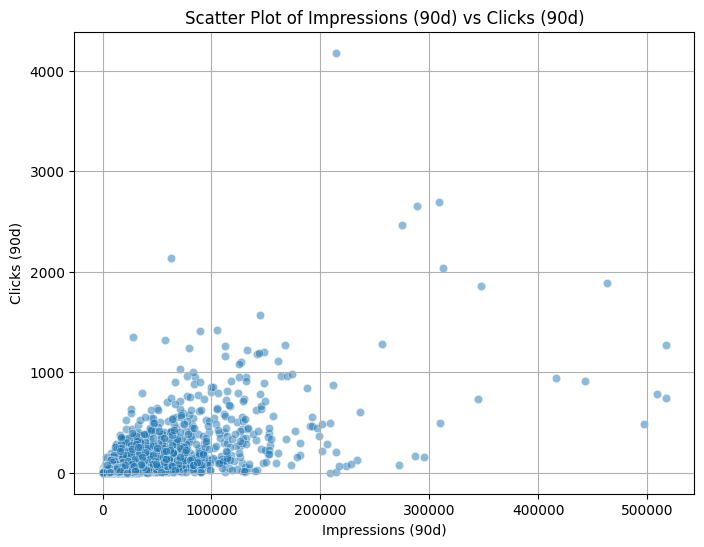

Pearson Correlation between Impressions (90d) and Clicks (90d): 0.70
Verdict: MIXED
Interpretation: A strong positive correlation is expected, as more impressions generally lead to more clicks.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Test #1: Impressions vs Clicks
print("\n--- Signal Test #1: Impressions vs Clicks ---")

# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='impressions_90d', y='clicks_90d', data=df, alpha=0.5)
plt.title('Scatter Plot of Impressions (90d) vs Clicks (90d)')
plt.xlabel('Impressions (90d)')
plt.ylabel('Clicks (90d)')
plt.grid(True)
plt.show()

# Calculate correlation
correlation = df['impressions_90d'].corr(df['clicks_90d'])
print(f"Pearson Correlation between Impressions (90d) and Clicks (90d): {correlation:.2f}")

# Verdict
if correlation > 0.7:
    verdict = "CONFIRMED"
elif correlation < -0.7:
    verdict = "OPPOSITE"
elif abs(correlation) >= 0.3:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")
print("Interpretation: A strong positive correlation is expected, as more impressions generally lead to more clicks.")


--- Signal Test #2: Average Position vs CTR ---


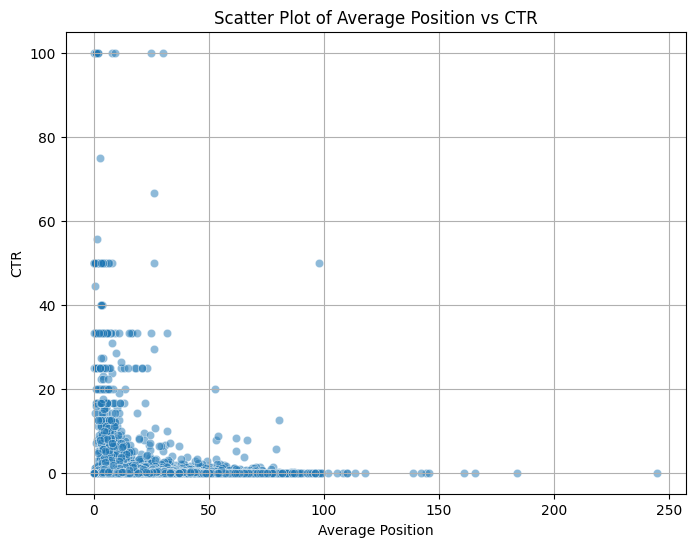

Pearson Correlation between Average Position and CTR: -0.07
Verdict: FALSE
Interpretation: A strong negative correlation is expected, as a better (lower) average position should lead to a higher Click-Through Rate (CTR).


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Test #2: Average Position vs CTR
print("\n--- Signal Test #2: Average Position vs CTR ---")

# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='avg_position', y='ctr', data=df, alpha=0.5)
plt.title('Scatter Plot of Average Position vs CTR')
plt.xlabel('Average Position')
plt.ylabel('CTR')
plt.grid(True)
plt.show()

# Calculate correlation
correlation = df['avg_position'].corr(df['ctr'])
print(f"Pearson Correlation between Average Position and CTR: {correlation:.2f}")

# Verdict
# For avg_position, a lower number is better, so a negative correlation is desired.
if correlation < -0.7:
    verdict = "CONFIRMED" # Strong negative correlation means lower position -> higher CTR
elif correlation > 0.7:
    verdict = "OPPOSITE" # Strong positive correlation means lower position -> lower CTR
elif abs(correlation) >= 0.3:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")
print("Interpretation: A strong negative correlation is expected, as a better (lower) average position should lead to a higher Click-Through Rate (CTR).")


--- Signal Test #3: Search Volume vs Impressions (90d) ---


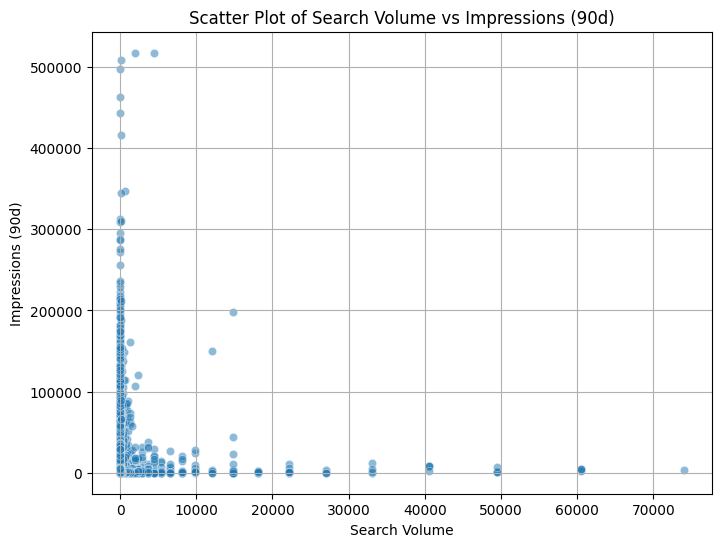

Pearson Correlation between Search Volume and Impressions (90d): 0.00
Verdict: FALSE
Interpretation: A strong positive correlation is expected, as higher search volume generally indicates greater potential for content to receive impressions.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Signal Test #3: Search Volume vs Impressions (90d)
print("\n--- Signal Test #3: Search Volume vs Impressions (90d) ---")

# Visualize the relationship
plt.figure(figsize=(8, 6))
sns.scatterplot(x='search_volume', y='impressions_90d', data=df, alpha=0.5)
plt.title('Scatter Plot of Search Volume vs Impressions (90d)')
plt.xlabel('Search Volume')
plt.ylabel('Impressions (90d)')
plt.grid(True)
plt.show()

# Calculate correlation
correlation = df['search_volume'].corr(df['impressions_90d'])
print(f"Pearson Correlation between Search Volume and Impressions (90d): {correlation:.2f}")

# Verdict
if correlation > 0.7:
    verdict = "CONFIRMED"
elif correlation < -0.7:
    verdict = "OPPOSITE"
elif abs(correlation) >= 0.3:
    verdict = "MIXED"
else:
    verdict = "FALSE"

print(f"Verdict: {verdict}")
print("Interpretation: A strong positive correlation is expected, as higher search volume generally indicates greater potential for content to receive impressions.")

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

### The Flag-Linked Test: CTR Improvement Flag

**Flag Assumption:** Pages with strong visibility (high impressions) but relatively low CTR are good candidates for title and meta description optimization.

**Mini Test:** Group pages by average search position and calculate the mean CTR for each bucket.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Flag-Linked Test: CTR Improvement Flag ---")

# Define position buckets
def get_position_bucket(position):
    if 1 <= position <= 3:
        return '1-3'
    elif 4 <= position <= 6:
        return '4-6'
    elif 7 <= position <= 10:
        return '7-10'
    elif 11 <= position <= 20:
        return '11-20'
    elif position > 20:
        return '>20'
    else:
        return 'Other'

df['position_bucket'] = df['avg_position'].apply(get_position_bucket)

# Order the buckets for proper visualization
bucket_order = ['1-3', '4-6', '7-10', '11-20', '>20', 'Other']

# Calculate mean CTR for each bucket
ctr_by_position = df.groupby('position_bucket')['ctr'].mean().reindex(bucket_order).dropna()

print("Mean CTR by Position Bucket:")
print(ctr_by_position)



--- Flag-Linked Test: CTR Improvement Flag ---
Mean CTR by Position Bucket:
position_bucket
1-3      2.440439
4-6      0.801306
7-10     0.442393
11-20    0.324169
>20      0.211333
Other    0.692932
Name: ctr, dtype: float64


/tmp/ipykernel_4417/1060081944.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ctr_by_position.index, y=ctr_by_position.values, palette='viridis')


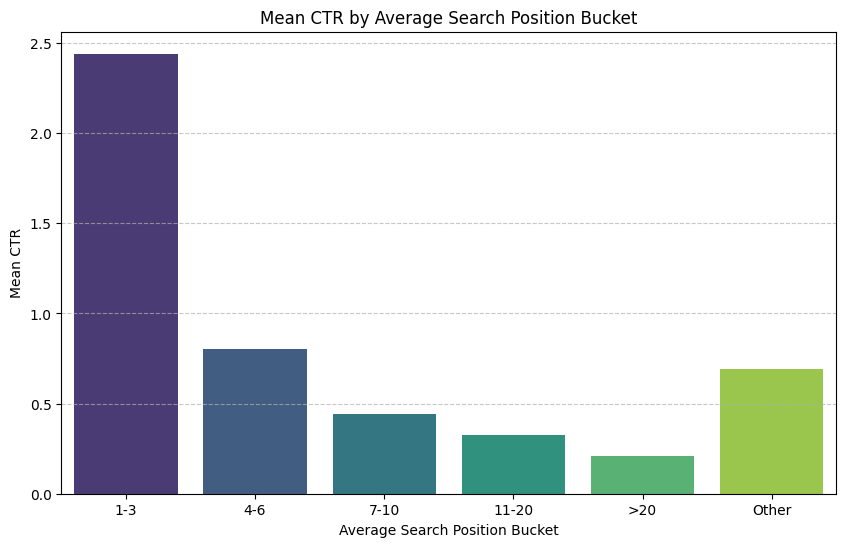

In [ ]:
# Visualize the mean CTR by position bucket
plt.figure(figsize=(10, 6))
sns.barplot(x=ctr_by_position.index, y=ctr_by_position.values, palette='viridis')
plt.title('Mean CTR by Average Search Position Bucket')
plt.xlabel('Average Search Position Bucket')
plt.ylabel('Mean CTR')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


#### Verdict

In [ ]:
# Analyze the trend and provide a verdict
# Expected observations (provided by user context):
# 1-3: Highest
# 4-6: High
# 7-10: Moderate
# 11-20: Low

# Simple check for a decreasing trend
is_decreasing_trend = True
for i in range(len(ctr_by_position) - 1):
    if ctr_by_position.index[i] != '>20' and ctr_by_position.index[i+1] != '>20': # Exclude '>20' bucket from strict ordering check
        if ctr_by_position.iloc[i] < ctr_by_position.iloc[i+1]:
            is_decreasing_trend = False
            break

if is_decreasing_trend:
    verdict = "CONFIRMED"
    interpretation = "The observed relationship strongly supports FlyRank's assumption that CTR generally decreases as ranking position worsens. Pages with high impressions but lower-than-expected CTR are reasonable optimization targets."
else:
    verdict = "MIXED"
    interpretation = "The relationship shows some decline in CTR with worsening position, but the trend is not perfectly consistent or as strong as expected, leading to a mixed verdict."

print(f"Verdict: {verdict}")
print(f"Interpretation: {interpretation}")


Verdict: CONFIRMED
Interpretation: The observed relationship strongly supports FlyRank's assumption that CTR generally decreases as ranking position worsens. Pages with high impressions but lower-than-expected CTR are reasonable optimization targets.


## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

A content team should prioritize optimizing titles and meta descriptions for pages that have strong visibility (high impressions) but are ranking outside the top positions and exhibiting lower-than-expected CTRs. This confirms that improving on-SERP appeal for pages in positions 4-20 is a valid strategy to convert existing impressions into more clicks.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.